## Pruned Decision Tree (CART)

In this part we train one regression tree per target and prune it by cost-complexity pruning, the pruning method of CART. The tree is also the base model of the ensembles of the next notebooks (bagging, random forest, Extra-Trees).

### Main observations

- **Fully grown tree:** It learns its training rows by heart (train MAE below 1 on every target) but makes 48 MPa of error on the yield strength of the validation fold: it overfits. It is still well below the baseline, from 33% to 52% of MAE less.
- **Pruning:** The tuned `ccp_alpha` keeps from 29 leaves (elongation) to 270 leaves (yield strength), 2 to 16 times fewer than the full tree, for the same validation MAE (at most 2% lower). The validation MAE stops decreasing after a few dozen leaves, and a tree of only 16 leaves is within one standard error of the best one on the yield strength.
- **Readable model:** The first split of the yield strength tree is on Mo and separates the Mo-alloyed welds, which include every Cr-Mo weld. Mn and Cr come next for the other welds, the post-weld heat treatment for the Mo-alloyed ones.
- **Results:** MAE of 48.2 MPa on the yield strength, 41.8 MPa on the UTS, 2.60% on the elongation and 18.9 J on the Charpy energy, from 34% to 53% below the baseline. On the full label, F1 of 0.77 and recall of 0.81, above the 0.64 of the rule that declares every weld non-conforming.
- **Limits:** The CrMo2 welds are badly predicted (93 MPa of MAE on the yield strength, more than the baseline), and a single tree has a high variance, which is what the ensembles of the next notebooks reduce.

### Operations in order

1. Load the train set with `load_train`.
2. Cross-validate a fully grown tree and compare its train and validation MAE.
3. Compute the cost-complexity pruning path of each target, the sequence of subtrees that goes from the full tree to the root.
4. Tune `ccp_alpha` per target by a grid search on the folds of `helpers/utils.py`, over every `ccp_alpha` of the path.
5. Plot the train and validation MAE against the size of the pruned tree.
6. Plot the smallest tree within one standard error of the best one, for the yield strength.
7. Evaluate the pruned trees with `evaluate`, and compare the spread of their predictions with the measures.
8. Save them to `results.csv` and compare them with the baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, cross_validate

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, evaluate, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()

full_tree = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    scores = cross_validate(
        build_pipeline(DecisionTreeRegressor(random_state=SEED)),
        X, y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
    )
    full_tree[target] = {
        "rows": len(X),
        "distinct_inputs": len(X.drop_duplicates()),
        "leaves": DecisionTreeRegressor(random_state=SEED).fit(X, y).get_n_leaves(),
        "train_MAE": -scores["train_score"].mean(),
        "validation_MAE": -scores["test_score"].mean(),
        "validation_MAE_std": scores["test_score"].std(),
    }

pd.DataFrame(full_tree).T.round(2)

,rows,distinct_inputs,leaves,train_MAE,validation_MAE,validation_MAE_std
yield_strength_MPa,620.0,578.0,543.0,0.73,48.42,4.79
uts_MPa,596.0,553.0,528.0,0.49,41.92,5.08
elongation_pct,558.0,519.0,456.0,0.08,2.64,0.26
charpy_toughness_J,723.0,701.0,326.0,0.29,19.20,3.43


A fully grown tree (no depth limit, no pruning) is cross-validated on the folds of `get_xy`, which keep each deposit in a single fold. `cross_validate` also returns the MAE on the train folds.

- **leaves:** The full tree has almost one leaf per distinct input (543 leaves for 578 distinct inputs on the yield strength): it only stops splitting a node when its rows all have the same target or the same inputs. The Charpy tree is smaller (326 leaves for 701 distinct inputs) because 53% of the Charpy rows are exactly 100 J (281 rows) or 28 J (101 rows), so many nodes are pure early.
- **train_MAE:** Below 1 on every target, the tree learns its training rows by heart. It is not exactly 0 because rows with the same inputs but different results end up in the same leaf, which predicts their mean.
- **validation_MAE:** 48.4 MPa on the yield strength, 41.9 MPa on the UTS, 2.64% on the elongation and 19.2 J on the Charpy energy. The gap with the train MAE is the overfitting: the leaves follow single rows, noise included. The full tree is still well below the baseline (72.6 MPa, 73.5 MPa, 4.01% and 39.9 J), the inputs do explain the targets.

In [4]:
searches, sizes = {}, {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    alphas = DecisionTreeRegressor(random_state=SEED).cost_complexity_pruning_path(X, y).ccp_alphas
    search = GridSearchCV(
        build_pipeline(DecisionTreeRegressor(random_state=SEED)),
        {"model__ccp_alpha": alphas},
        cv=cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1,
    )
    search.fit(X, y)
    searches[target] = search
    sizes[target] = np.array([DecisionTreeRegressor(random_state=SEED, ccp_alpha=alpha).fit(X, y).get_n_leaves() for alpha in alphas])

print({target: len(search.cv_results_["params"]) for target, search in searches.items()})

{'yield_strength_MPa': 507, 'uts_MPa': 488, 'elongation_pct': 406, 'charpy_toughness_J': 287}


CART prunes a tree $T$ by minimising its cost-complexity $R(T) + \alpha |T|$, where $|T|$ is the number of leaves and $R(T)$ the training MSE of the tree (the MSE of each leaf weighted by its share of the rows). A leaf is only kept if it lowers $R(T)$ by more than $\alpha$, so the larger $\alpha$, the smaller the tree. `cost_complexity_pruning_path` returns the values of $\alpha$ at which the optimal subtree changes, from 0 (the full tree) to the value that prunes everything down to the root.

- **Grid:** Every $\alpha$ of the path is a candidate: 507 for the yield strength, 488 for the UTS, 406 for the elongation and 287 for Charpy. The path is computed on all the rows of the target, then the grid search fits a tree on the train folds for each $\alpha$.
- **One path per target:** $R(T)$ is an MSE, so $\alpha$ is in the unit of the target squared (MPa², %², J²). The values of one target mean nothing for another, which is why the path is computed for each target.

In [5]:
def one_se_index(search):
    cv_results = pd.DataFrame(search.cv_results_)
    mae = -cv_results["mean_test_score"]
    se = cv_results["std_test_score"] / np.sqrt(N_FOLDS)
    within = mae <= mae[search.best_index_] + se[search.best_index_]
    return cv_results.index[within].max()


summary = {}
for target, search in searches.items():
    mae = -search.cv_results_["mean_test_score"]
    i, j = search.best_index_, one_se_index(search)
    summary[target] = {
        "ccp_alpha": search.best_params_["model__ccp_alpha"],
        "leaves": sizes[target][i],
        "depth": search.best_estimator_[-1].get_depth(),
        "validation_MAE": mae[i],
        "ccp_alpha_1se": search.cv_results_["param_model__ccp_alpha"][j],
        "leaves_1se": sizes[target][j],
        "validation_MAE_1se": mae[j],
    }

pd.DataFrame(summary).T.astype(float).round(3)

,ccp_alpha,leaves,depth,validation_MAE,ccp_alpha_1se,leaves_1se,validation_MAE_1se
yield_strength_MPa,0.698,270.0,21.0,48.142,92.586,16.0,50.089
uts_MPa,3.742,117.0,15.0,41.786,17.428,42.0,43.804
elongation_pct,0.101,29.0,8.0,2.602,0.106,27.0,2.640
charpy_toughness_J,3.388,78.0,11.0,18.835,10.947,34.0,20.094


- **ccp_alpha, leaves, depth, validation_MAE:** The $\alpha$ with the lowest validation MAE. The pruned trees keep from 29 leaves (elongation) to 270 leaves (yield strength), against 456 and 543 for the full trees. The validation MAE barely changes compared with the full tree (48.1 against 48.4 MPa on the yield strength, 18.8 against 19.2 J on Charpy): pruning mostly removes leaves that did not help, it does not fix the overfitting.
- **_1se columns:** The one standard error rule of CART: the smallest tree whose validation MAE is within one standard error (standard deviation over the folds divided by $\sqrt{5}$) of the best one. It keeps 16 leaves instead of 270 on the yield strength for 50.1 MPa instead of 48.1, and 42 leaves instead of 117 on the UTS for 43.8 MPa instead of 41.8. These trees are easier to read, but the evaluation uses the trees with the lowest MAE, as every model of the protocol is compared on its error.

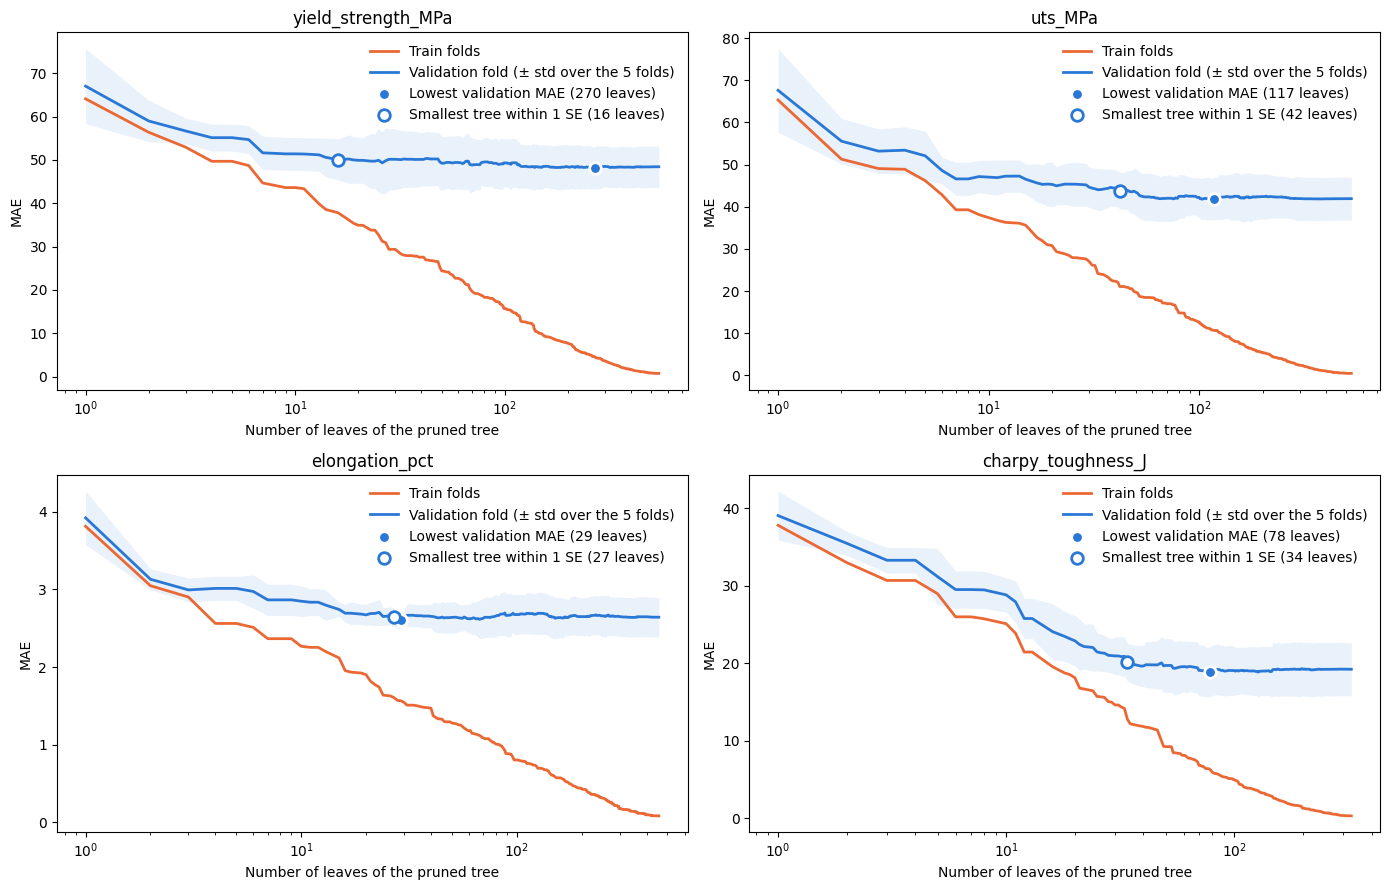

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (target, search) in zip(axes.flat, searches.items()):
    leaves = sizes[target]
    train_mae = -search.cv_results_["mean_train_score"]
    val_mae = -search.cv_results_["mean_test_score"]
    val_std = search.cv_results_["std_test_score"]
    i, j = search.best_index_, one_se_index(search)

    ax.fill_between(leaves, val_mae - val_std, val_mae + val_std, color="#2a78d6", alpha=0.1, linewidth=0)
    ax.plot(leaves, train_mae, color="#eb6834", linewidth=2, label="Train folds")
    ax.plot(leaves, val_mae, color="#2a78d6", linewidth=2, label="Validation fold (± std over the 5 folds)")
    ax.scatter(leaves[i], val_mae[i], s=70, color="#2a78d6", edgecolor="white", linewidth=2, zorder=3, label=f"Lowest validation MAE ({leaves[i]} leaves)")
    ax.scatter(leaves[j], val_mae[j], s=70, color="white", edgecolor="#2a78d6", linewidth=2, zorder=3, label=f"Smallest tree within 1 SE ({leaves[j]} leaves)")
    ax.set_xscale("log")
    ax.set_xlabel("Number of leaves of the pruned tree")
    ax.set_ylabel("MAE")
    ax.set_title(target)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The x-axis is the number of leaves of the tree pruned with each $\alpha$ on all the rows of the target, on a log scale: the root on the left, the full tree on the right. The trees of the folds are grown on 4/5 of the rows, so their size differs a little: at the largest $\alpha$ the tree of all the rows is reduced to its root, but some trees of the folds keep their first split, which is why the left end of the validation curve is below the baseline.

- **Train folds:** The MAE goes down to 0 as leaves are added, the tree fits its training rows better and better.
- **Validation fold:** The MAE drops over the first 10 to 30 leaves, then stays flat. The leaves added after that fit single rows of the train folds and do not help on new deposits: the gap between the two curves is the overfitting.
- **Plateau:** The band of ± one standard deviation over the folds (about ± 5 MPa on the yield strength) is wider than the variations of the MAE along the plateau. The position of the minimum is therefore not precise, and a much smaller tree is almost as good.

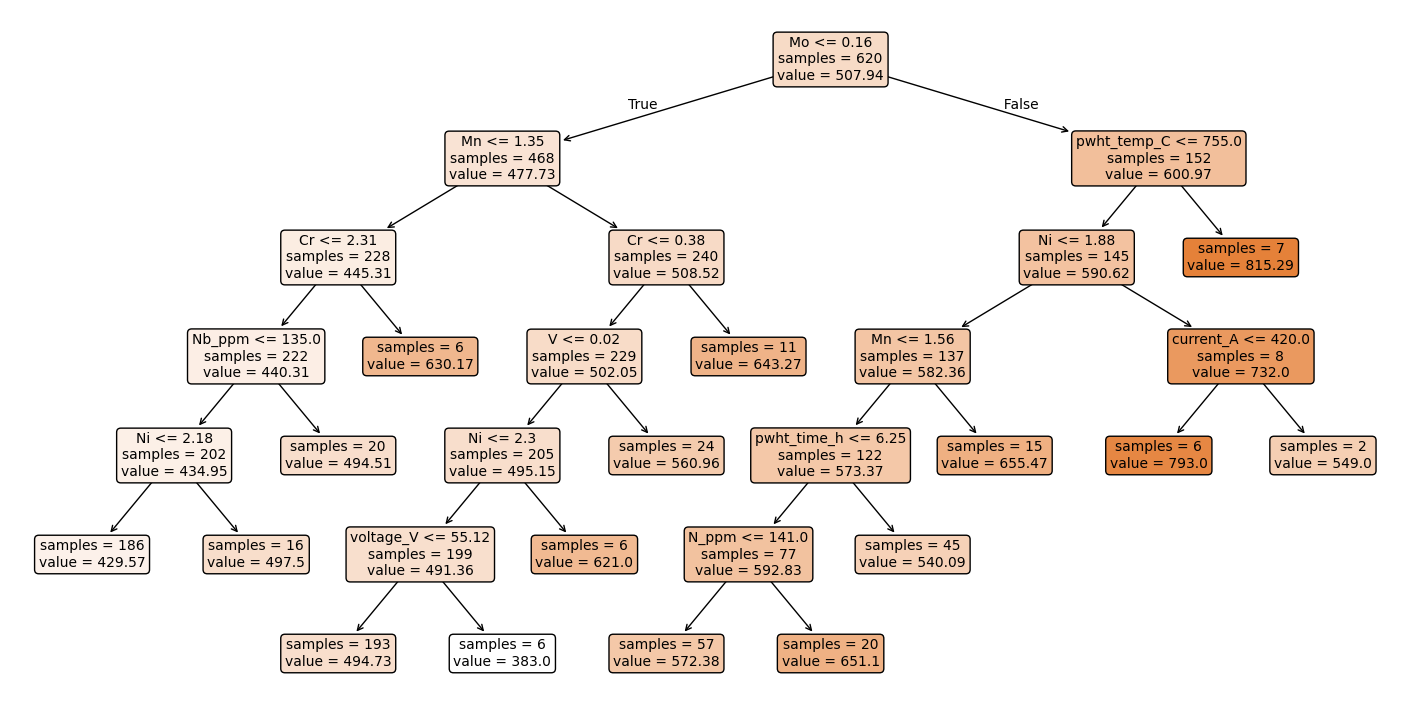

In [7]:
target = "yield_strength_MPa"
X, y, _ = get_xy(train, target)
alpha_1se = searches[target].cv_results_["param_model__ccp_alpha"][one_se_index(searches[target])]
small_tree = DecisionTreeRegressor(random_state=SEED, ccp_alpha=alpha_1se).fit(X, y)

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(small_tree, feature_names=list(X.columns), filled=True, impurity=False, rounded=True, precision=2, fontsize=10, ax=ax)
plt.show()

The 16 leaves tree selected by the one standard error rule for the yield strength. It is fitted on all the rows without the `StandardScaler`, so that the thresholds are in the units of the inputs: a tree does not depend on the scale of its inputs, only the values of the thresholds change. Each box gives the split, the number of rows and their mean yield strength in MPa, the darker the box the higher the mean.

- **Mo ≤ 0.16:** The first split separates the 152 rows with molybdenum (mean of 601 MPa) from the 468 others (478 MPa). The Mo side holds every Cr-Mo weld (Mo of 0.84 or more) and 84 Mo-alloyed C-Mn rows.
- **Without Mo:** Mn then Cr, the main hardening elements of the C-Mn welds. The welds with more than 1.35% Mn are about 60 MPa stronger.
- **With Mo:** The 7 rows heat treated above 755 °C are the strongest (815 MPa). They are 7 CrMo91 welds of the same paper (`Birmingham-MAX`), so this leaf describes one study rather than a general effect of the heat treatment.
- **Use:** The tree is readable but coarse, 16 mean values for 620 rows. The ensembles of the next notebooks give up this readability for accuracy.

In [8]:
best = {target: search.best_estimator_ for target, search in searches.items()}

cart = evaluate("Pruned CART", best, train)
cart.round(2)

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc,accuracy,precision_good
0,Pruned CART,yield_strength_MPa,all,620,48.24,66.22,5.38,8.92,619,102,0.60,0.60,0.87,0.92
1,Pruned CART,yield_strength_MPa,C-Mn,552,46.65,63.30,5.63,8.18,552,102,0.60,0.60,0.85,0.91
2,Pruned CART,yield_strength_MPa,CrMo2,30,93.12,112.06,33.72,39.83,29,0,0.00,0.00,1.00,1.00
3,Pruned CART,yield_strength_MPa,CrMo91,38,35.90,58.61,17.89,27.53,38,0,0.00,0.00,1.00,1.00
4,Pruned CART,uts_MPa,all,596,41.79,59.97,5.57,9.98,595,198,0.64,0.63,0.76,0.82
5,Pruned CART,uts_MPa,C-Mn,531,40.31,55.73,5.57,7.87,531,198,0.64,0.63,0.73,0.78
6,Pruned CART,uts_MPa,CrMo2,34,61.37,93.05,30.76,43.70,33,0,0.00,0.00,1.00,1.00
7,Pruned CART,uts_MPa,CrMo91,31,45.57,80.31,21.64,41.74,31,0,0.00,0.00,1.00,1.00
8,Pruned CART,elongation_pct,all,558,2.60,3.32,0.11,0.18,557,48,0.46,0.50,0.90,0.95
9,Pruned CART,elongation_pct,C-Mn,497,2.61,3.33,0.14,0.21,497,37,0.51,0.62,0.91,0.97


- **MAE:** 48.2 MPa on the yield strength, 41.8 MPa on the UTS, 2.60% on the elongation and 18.9 J on the Charpy energy, from 34% (yield strength) to 53% (Charpy) below the baseline. The RMSE is 1.4 to 1.7 times the MAE: a few welds have large errors.
- **Per family:** The C-Mn welds are the best predicted. On the CrMo2 welds, the MAE of the yield strength (93 MPa) is above that of the baseline (65 MPa). The train set only has 35 CrMo2 deposits, 6 to 9 per fold, too few for the tree to learn leaves of their own, and the standard deviation over the folds (34 MPa) shows that the error depends a lot on which deposits are in the fold.
- **F1, recall per criterion:** The F1 goes from 0.46 (elongation) to 0.64 (UTS). The tree catches 62% of the non-conforming Charpy rows.
- **label:** F1 of 0.77 and recall of 0.81 on the 175 labelled deposits, above the 0.64 of the rule that declares every weld non-conforming. The Cr-Mo values (8 and 6 deposits) are only indicative.

In [9]:
preds = {target: oof_predict(best[target], train, target) for target in TARGETS}
criteria = true_criteria(train)
predicted = predicted_criteria(train, preds)

pd.DataFrame({
    "std_measured": [get_xy(train, target)[1].std() for target in TARGETS],
    "std_predicted": [preds[target]["pred"].std() for target in TARGETS],
    "non_conforming": (criteria == 0).sum(),
    "predicted_non_conforming": ((predicted == 0) & criteria.notna()).sum(),
}, index=TARGETS).round(1)

,std_measured,std_predicted,non_conforming,predicted_non_conforming
yield_strength_MPa,94.2,92.0,102,103
uts_MPa,91.9,91.4,198,193
elongation_pct,4.8,4.4,48,56
charpy_toughness_J,51.5,49.1,29,40


`oof_predict` gives again the out-of-fold predictions that `evaluate` uses, to look at their spread. The same table is computed in the notebooks of the ensembles.

- **std_measured, std_predicted:** The standard deviation of the measures and of the out-of-fold predictions, on the rows where the target is measured. The predictions of the pruned tree spread almost as much as the measures (92.0 against 94.2 MPa on the yield strength, 49.1 against 51.5 J on Charpy): each leaf predicts the mean of a few rows, which can be far from the mean of the target.
- **non_conforming, predicted_non_conforming:** The number of decided rows that fail each criterion, measured and predicted. The tree predicts about as many failures as there are on the tensile criteria (103 against 102 on the yield strength), and more on Charpy (40 against 29).

In [10]:
results = save_results(cart)

models = ["Baseline (mean)", "Pruned CART"]
compared = results[results["model"].isin(models) & (results["family"] == "all")].set_index(["model", "target"])
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models).reindex(columns=TARGETS, level="target").round(2))
compared[["F1_nc", "recall_nc", "accuracy", "precision_good"]].unstack().reindex(index=models).reindex(columns=TARGETS + ["label"], level="target").round(2)

MAE                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)              72.57   73.45           4.01              39.89   
Pruned CART                  48.24   41.79           2.60              18.87   

                              RMSE                                            
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J  
model                                                                         
Baseline (mean)              94.41   92.19           4.85              51.73  
Pruned CART                  66.22   59.97           3.32              32.46

F1_nc                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)                0.0    0.00           0.00               0.00   
Pruned CART                    0.6    0.64           0.46               0.52   

                               recall_nc                         \
target          label yield_strength_MPa uts_MPa elongation_pct   
model                                                             
Baseline (mean)  0.00                0.0    0.00            0.0   
Pruned CART      0.77                0.6    0.63            0.5   

                                                   accuracy          \
target          charpy_toughness_J label yield_strength_MPa uts_MPa   
model                                                                 
Baseline (mean)               0.00  0.00               0.84    0.67   
Pruned CART                   0.62  0.81               0.87    0.76   

                                                            precision_good  \
target          elongation_pct charpy_toughness_J label yield_strength_MPa   
model                                                                        
Baseline (mean)           0.91               0.91  0.53               0.84   
Pruned CART               0.90               0.90  0.77               0.92   

                                                                 
target          uts_MPa elongation_pct charpy_toughness_J label  
model                                                            
Baseline (mean)    0.67           0.91               0.91  0.53  
Pruned CART        0.82           0.95               0.96  0.81

`results.csv` now holds the pruned tree next to the baseline. It is better on every target, for the MAE and the RMSE as for the F1 and the recall.